In [16]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from tqdm import tqdm
from typing import Tuple, List
from scipy.signal import resample
import os
import glob
from pathlib import Path
import yaml

In [17]:
def segment_signal(signal, segment_length, step=None, overlap=None, apply_window=True):
    if step is not None:
        segments = [
            signal[i : i + segment_length]
            for i in range(0, len(signal) - segment_length + 1, step)
        ]
    elif overlap is not None:
        step = int(segment_length * (1 - overlap))
        segments = [
            signal[i : i + segment_length]
            for i in range(0, len(signal) - segment_length + 1, step)
        ]
    else:
        raise ValueError("Either 'step' or 'overlap' must be specified.")
    return np.array(segments)


def time_to_freq_transform(data, f_sampling, db=True, cutoff_freq=None):
    if data.ndim != 1:
        raise ValueError(
            f"Input data must be a 1D NumPy array. Got shape {data.shape}."
        )
    n = data.shape[0] 
    yf = np.fft.rfft(data) 
    freqs = np.fft.rfftfreq(n, d=1 / f_sampling) 
    if cutoff_freq is not None:
        mask = freqs < cutoff_freq 
        yf = yf[mask]
        freqs = freqs[mask]
    yf = np.abs(yf)  
    if db:
        eps = np.finfo(float).eps  
        yf = 20 * np.log10(yf + eps)  
    return yf, freqs


def perform_fft_on_segments(
    segments, f_sampling, db=True, cutoff_freq=250, remove_dc=False
):
    segs = segments.copy()
    if remove_dc:
        segs -= segs.mean(axis=1, keepdims=True)
    num_segments, segment_length = segs.shape
    full_freqs = np.fft.rfftfreq(segment_length, d=1 / f_sampling)
    cutoff_mask = full_freqs < cutoff_freq
    fft_output_length = np.sum(cutoff_mask)

    fft_segments = np.zeros((num_segments, fft_output_length))
    for i in range(num_segments):
        fft_segments[i], freqs = time_to_freq_transform(
            segments[i], f_sampling, db=db, cutoff_freq=cutoff_freq
        )
    return fft_segments, freqs


def get_mean_and_std(fft_segments):
    spectrum_mean = np.mean(fft_segments, axis=0)
    spectrum_std = np.std(fft_segments, axis=0)
    return spectrum_mean, spectrum_std


def tight_plots(ax):
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


def plot_single_segment_with_uncertainty(fft_segments, 
                                         x_values=None, 
                                         max_points=1000, 
                                         n_std=2, 
                                         title="Spectrum with Uncertainty",
                                         axis_labels=None, 
                                         highlight_freqs=None, 
                                         method='closest',
                                         inplace=True):
    spectrum_mean = np.mean(fft_segments, axis=0)
    spectrum_std = np.std(fft_segments, axis=0) * n_std 
    if max_points is not None and len(spectrum_mean) > max_points:
        spectrum_mean = resample(spectrum_mean, max_points)
        spectrum_std = resample(spectrum_std, max_points)
        if x_values is not None:
            if len(x_values.shape) == 1:
                x_values = resample(x_values, max_points)
            else:
                x_values = resample(x_values, max_points)
        else:
            x_values = np.linspace(0, len(spectrum_mean), len(spectrum_mean))
    else:
        if x_values is None:
            x_values = np.linspace(0, len(spectrum_mean), len(spectrum_mean))

    x_label, y_label = axis_labels if axis_labels else ('Frequency, Hz', 'Power, dB')
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(x_values, spectrum_mean, linewidth=2.0, color='blue', label='Mean Spectrum')
    ax.fill_between(
        x_values,
        spectrum_mean - spectrum_std,
        spectrum_mean + spectrum_std,
        color='blue',
        alpha=0.2,
        label=f'Uncertainty (±{n_std} SD)'
    )
    ax.plot(x_values, spectrum_mean - spectrum_std, linewidth=1.0, color='darkblue', linestyle='--')
    ax.plot(x_values, spectrum_mean + spectrum_std, linewidth=1.0, color='darkblue', linestyle='--')
    if highlight_freqs is not None and len(highlight_freqs) > 0:
        for freq in highlight_freqs:
            if method == 'closest':
                closest_idx = np.abs(x_values - freq).argmin()
                ax.scatter(x_values[closest_idx], spectrum_mean[closest_idx], color='red', s=50)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel(x_label, fontsize=9)
    ax.set_ylabel(y_label, fontsize=9)
    ax.grid(True, linestyle='--', linewidth=0.5)
    if inplace:
        tight_plots(ax)
    return fig, ax


def create_metadata_df(base_dir: str, state2name: dict | None = None) -> pd.DataFrame:
    csv_pattern = os.path.join(base_dir, "experiment_*", "current", "*", "*", "*.csv")
    csv_files = glob.glob(csv_pattern)
    metadata_list = []
    for file_path in csv_files:
        parts = file_path.split(os.sep)
        try:
            experiment = parts[-5]  
            load_folder = parts[-3] 
            phase = parts[-2] 
            base_id = os.path.splitext(os.path.basename(file_path))[0]
            measurement_id = base_id + f"_{phase}"
        except IndexError as e:
            print(f"File path {file_path} does not match expected structure: {e}")
            continue
        try:
            load_parts = load_folder.split("_")
            if len(load_parts) >= 3:
                state = load_parts[0][0] 
                load_condition = load_parts[-1] 
            else:
                state = None
                load_condition = load_folder
        except Exception as e:
            print(f"Error parsing load folder {load_folder} in file {file_path}: {e}")
            state, load_condition = None, None
        try:
            df = pd.read_csv(file_path, header=0, index_col=0)
        except Exception as e:
            print(f"Error reading file {file_path}: {e}")
            continue
        df = df.dropna(axis=1, how="all")
        num_observations = df.shape[0]
        if state2name is not None:
            try:
                state = state2name[int(state)]
            except KeyError:
                print(f"Fault type {state} not found in mapping.")
                state = None
        meta_entry = {
            "measurement_id": measurement_id,
            "base_id": base_id,
            "experiment": experiment,
            "state": state,
            "load_condition": load_condition,
            "phase": phase,
            "num_observations": num_observations,
            "file_path": file_path,
            "engine_cfg_path": f"dataset/engine_2/engine.yml",
        }
        metadata_list.append(meta_entry)
    if metadata_list:
        metadata_df = pd.DataFrame(metadata_list)
        metadata_df.set_index("measurement_id", inplace=True)
    else:
        metadata_df = pd.DataFrame(
            columns=[
                "experiment",
                "state",
                "load_condition",
                "phase",
                "num_observations",
                "file_path",
                "engine_cfg_path",
            ]
        )
    return metadata_df


def load_measurement(measurement_id: str, metadata_df: pd.DataFrame) -> pd.DataFrame:
    if measurement_id not in metadata_df.index:
        raise KeyError(f"Measurement {measurement_id} not found in metadata.")
    file_path = metadata_df.loc[measurement_id, "file_path"]
    try:
        df = pd.read_csv(file_path, header=0, index_col=0)
    except Exception as e:
        raise Exception(f"Error reading file {file_path}: {e}")
    df = df.dropna(axis=1, how="all")
    df.columns = ["Time", "Current"]
    df.set_index("Time", inplace=True)
    df.sort_index(inplace=True)
    return df


def preprocessing(
    metadata_df: pd.DataFrame,
    out_dir: str,
    segment_length: int,
    step: int,
    f_sampling: int,
    cutoff_freq: int,
    apply_window: bool = False,
    db: bool = True,
) -> Tuple[np.ndarray, pd.DataFrame, np.ndarray]:
    seg_meta_rows: List[dict] = []
    seg_arrays: List[np.ndarray] = []
    for m_id, meta in tqdm(metadata_df.iterrows(),
                           total=len(metadata_df),
                           desc="pre-processing"):
        df = load_measurement(m_id, metadata_df)
        current = df["Current"].dropna().values
        windows = segment_signal(
            current,
            segment_length=segment_length,
            step=step,
            apply_window=apply_window,
        )
        fft_windows, freqs = perform_fft_on_segments(
            windows,
            f_sampling=f_sampling,
            cutoff_freq=cutoff_freq,
            db=db,
        )
        n_segments = fft_windows.shape[0]
        for s_idx in range(n_segments):
            start_t = df.index[s_idx * step]
            end_t   = df.index[s_idx * step + segment_length - 1]
            seg_meta_rows.append({
                "measurement_id": m_id,
                "segment_idx":    s_idx,
                "start_time":     float(start_t),
                "end_time":       float(end_t),
                "state":          meta["state"],
                "binary_label":   0 if meta["state"] == "normal" else 1,
                "multiclass_label": meta["state"],
                "phase":          int(meta["phase"]),
                "load_condition": meta["load_condition"],
                "experiment":     meta["experiment"],
            })
        seg_arrays.append(fft_windows.astype(np.float32))
    segments = np.vstack(seg_arrays) 
    seg_meta_df = (
        pd.DataFrame(seg_meta_rows)
          .set_index(["measurement_id", "segment_idx"])
    )
    os.makedirs(out_dir, exist_ok=True)
    np.save(os.path.join(out_dir, "segments.npy"), segments)
    np.save(os.path.join(out_dir, "freqs.npy"), freqs)
    seg_meta_df.to_csv(os.path.join(out_dir, "segments_metadata.csv"))
    return segments, seg_meta_df, freqs

In [18]:
with open("training_configs/train_engine-2.yml", "r") as f:
    train_params = yaml.safe_load(f)

f_sampling = train_params["processing_parameters"]["f_sampling"]
shift = train_params["processing_parameters"]["shift"]
segment_length = train_params["processing_parameters"]["segment_length"]
cutoff_freq = train_params["processing_parameters"]["cutoff_freq"]
peak_type = train_params["processing_parameters"]["peak_type"]
peak_segment = train_params["processing_parameters"]["peak_segment"]
amplitude_range = tuple(train_params["processing_parameters"]["amplitude_range"])
sigma_range = tuple(train_params["processing_parameters"]["sigma_range"])
noise_factor = train_params["processing_parameters"]["noise_factor"]
num_epochs_binary = train_params["training_parameters"]["num_epochs_binary"]
num_epochs_multi = train_params["training_parameters"]["num_epochs_multi"]
batch_size = train_params["data_parameters"]["batch_size"]
normalization_method = train_params["dataset_parameters"]["normalization_method"]

train_params

{'engineLabel': 'engine_2',
 'task': 'binary',
 'model': 'ResNet',
 'test_run': False,
 'comet_online': False,
 'seed': 42,
 'processing_parameters': {'f_sampling': 4098,
  'shift': 20,
  'segment_length': 10000,
  'cutoff_freq': 250,
  'db': True,
  'peak_type': 'gaussian',
  'peak_segment': 4,
  'amplitude_range': [0.5, 20.0],
  'sigma_range': [0.5, 1.5],
  'noise_factor': 0.0,
  'include_negative_peaks': True,
  'random_peak_position': True,
  'fault_types_to_use': ['inter-turn short circuits', 'rotor bar defect'],
  'loads_to_use': [0, 20, 40, 60, 80, 100],
  'phases_to_use': [1, 2, 3]},
 'model_parameters': {'attention_module': False, 'dropout': 0.2},
 'training_parameters': {'num_epochs_binary': 30,
  'num_epochs_multi': 30,
  'initial_lr': 0.001,
  'patience': 10},
 'data_parameters': {'batch_size': 4096},
 'dataset_parameters': {'batch_size': 4096,
  'normalization_method': 'min-max',
  'normalization_mode': 'global',
  'real_fault_train': 0,
  'test_size': 0.3,
  'val_size': 0

In [19]:
def get_state(x):
    for state in ['no_fault', 'short_circuit', 'broken_bar']:
        if state in x:
            return state


def get_phase(x):
    phase = x.split('\\')[-1].split('_')[-1].split('.')[0]
    return 1 if phase == 'phaseA' else 2 if phase == 'phaseB' else 3


def get_num_observations(x):
    return pd.read_csv(x).shape[0]


def get_measurement_id(x):
    return f'{x.state}_{x.phase}'

In [24]:
H_PATH = Path('./Simulations/АИР 80A2 1081_2081 Un-220 Vdc-380/no_fault')
SC_PATH = Path('./Simulations/АИР 80A2 1081_2081 Un-220 Vdc-380/short_circuit/fscnturns-90')
BB_PATH = Path('./Simulations/АИР 80A2 1081_2081 Un-220 Vdc-380/broken_bars/Nbars-5 nbroken-1')
simulated_files = list(map(str, H_PATH.glob('*.csv'))) + \
                  list(map(str, SC_PATH.glob('*.csv'))) + \
                  list(map(str, BB_PATH.glob('*.csv')))
simulated_df = pd.DataFrame({'file_path': simulated_files})
simulated_df['state'] = simulated_df.file_path.apply(get_state)
simulated_df['load_condition'] = 100
simulated_df['experiment'] = 'experiment_2'
simulated_df['phase'] = simulated_df.file_path.apply(get_phase)
simulated_df['num_observations'] = simulated_df.file_path.apply(get_num_observations)
simulated_df['measurement_id'] = simulated_df.apply(get_measurement_id, axis=1)
simulated_df = simulated_df.reset_index(drop=True).set_index('measurement_id')
simulated_df.head()

,file_path,state,load_condition,experiment,phase,num_observations
measurement_id,,,,,,
no_fault_1,Simulations\АИР 80A2 1081_2081 Un-220 Vdc-380\...,no_fault,100,experiment_2,1,75000
no_fault_2,Simulations\АИР 80A2 1081_2081 Un-220 Vdc-380\...,no_fault,100,experiment_2,2,75000
no_fault_3,Simulations\АИР 80A2 1081_2081 Un-220 Vdc-380\...,no_fault,100,experiment_2,3,75000
short_circuit_1,Simulations\АИР 80A2 1081_2081 Un-220 Vdc-380\...,short_circuit,100,experiment_2,1,75000
short_circuit_2,Simulations\АИР 80A2 1081_2081 Un-220 Vdc-380\...,short_circuit,100,experiment_2,2,75000


In [25]:
sim_seg = {}
sim_freqs = {}

sim_df_phase_1 = simulated_df[simulated_df.phase == 1]

for state in sim_df_phase_1.state.unique():
    sim_seg[state], _, sim_freqs[state] = preprocessing(sim_df_phase_1[sim_df_phase_1.state == state],
                                                        f'{state}_1',
                                                        segment_length=segment_length,
                                                        step=shift,
                                                        f_sampling=f_sampling,
                                                        cutoff_freq=cutoff_freq
                                                        )

pre-processing: 100%|██████████| 1/1 [00:00<00:00,  1.52it/s]


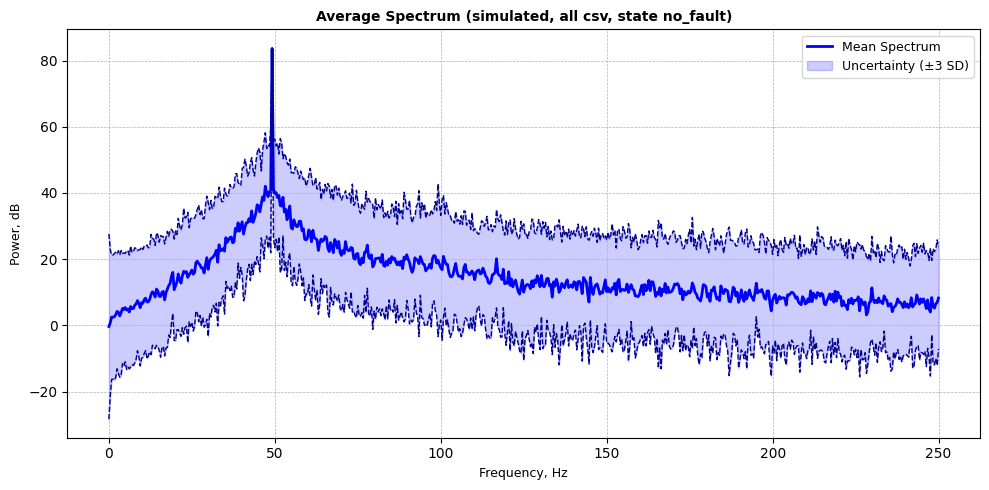

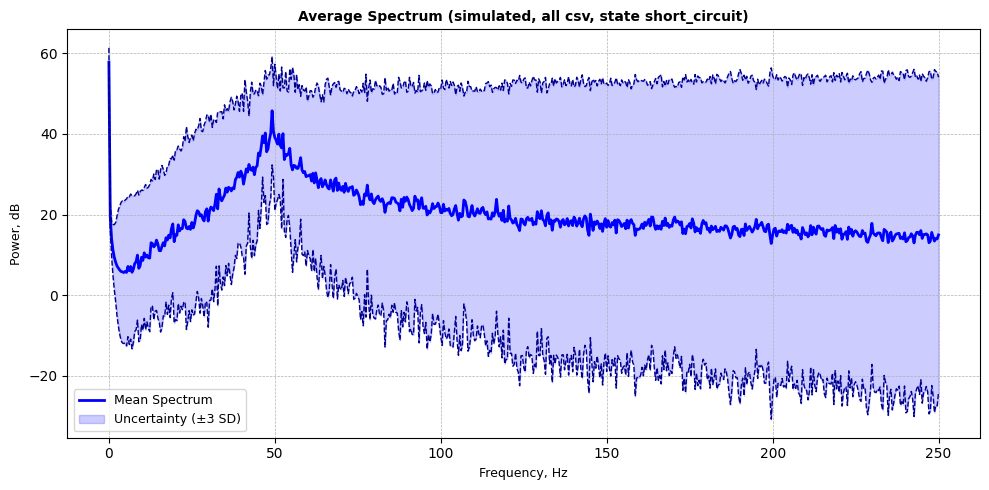

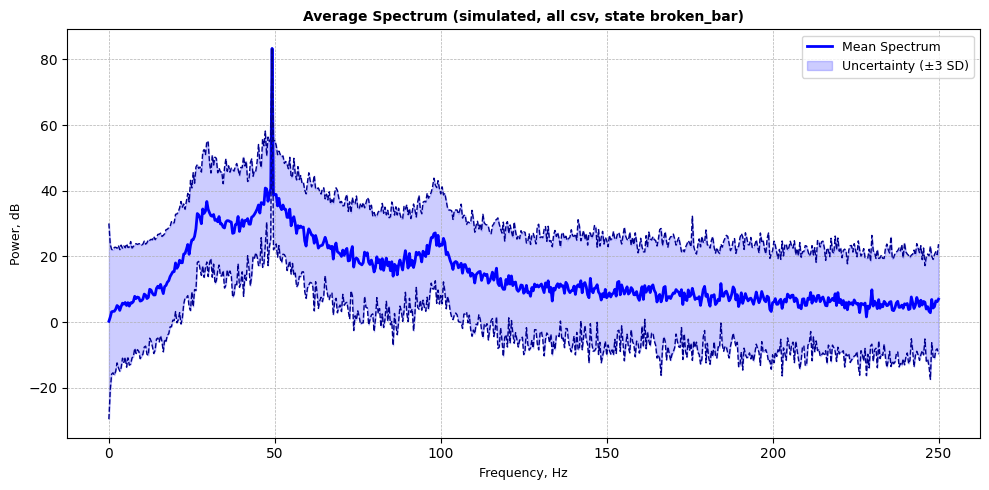

In [26]:
sim_means = {}
sim_std = {}

for state in sim_df_phase_1.state.unique():
    sim_means[state], sim_std[state] = get_mean_and_std(sim_seg[state])
    fig, ax = plot_single_segment_with_uncertainty(sim_seg[state], 
                                                   x_values=sim_freqs[state], 
                                                   n_std=3, 
                                                   title=f'Average Spectrum (simulated, all csv, state {state})',
                                                   inplace=True)